# Task 1: EDA & Preprocessing — CFPB Complaint Data

**Objective:** Understand the structure of complaint data and prepare it for the RAG pipeline.

**Author:** Sosina Ayele

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')
plt.style.use('ggplot')
print('Libraries loaded!')

Libraries loaded!


## 1. Load Data

In [3]:
paths = [
    '../data/raw/complaints.csv',
    r'c:\KAIM\rag-complaint-chatbot\data\raw\complaints.csv',
]
for p in paths:
    if os.path.exists(p):
        df = pd.read_csv(p, low_memory=False)
        print(f'Loaded: {df.shape}')
        break

print(f'Columns: {df.columns.tolist()}')
df.head(3)

Loaded: (9609797, 18)
Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


## 2. Initial EDA

In [4]:
print('=== Dataset Info ===')
print(f'Shape: {df.shape}')
print(f'\nData Types:')
print(df.dtypes)
print(f'\nMissing Values:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

=== Dataset Info ===
Shape: (9609797, 18)

Data Types:
Date received                   object
Product                         object
Sub-product                     object
Issue                           object
Sub-issue                       object
Consumer complaint narrative    object
Company public response         object
Company                         object
State                           object
ZIP code                        object
Tags                            object
Consumer consent provided?      object
Submitted via                   object
Date sent to company            object
Company response to consumer    object
Timely response?                object
Consumer disputed?              object
Complaint ID                     int64
dtype: object

Missing Values:
Tags                            8981029
Consumer disputed?              8841498
Consumer complaint narrative    6629041
Company public response         4770207
Consumer consent provided?      1649561
Sub-issue   

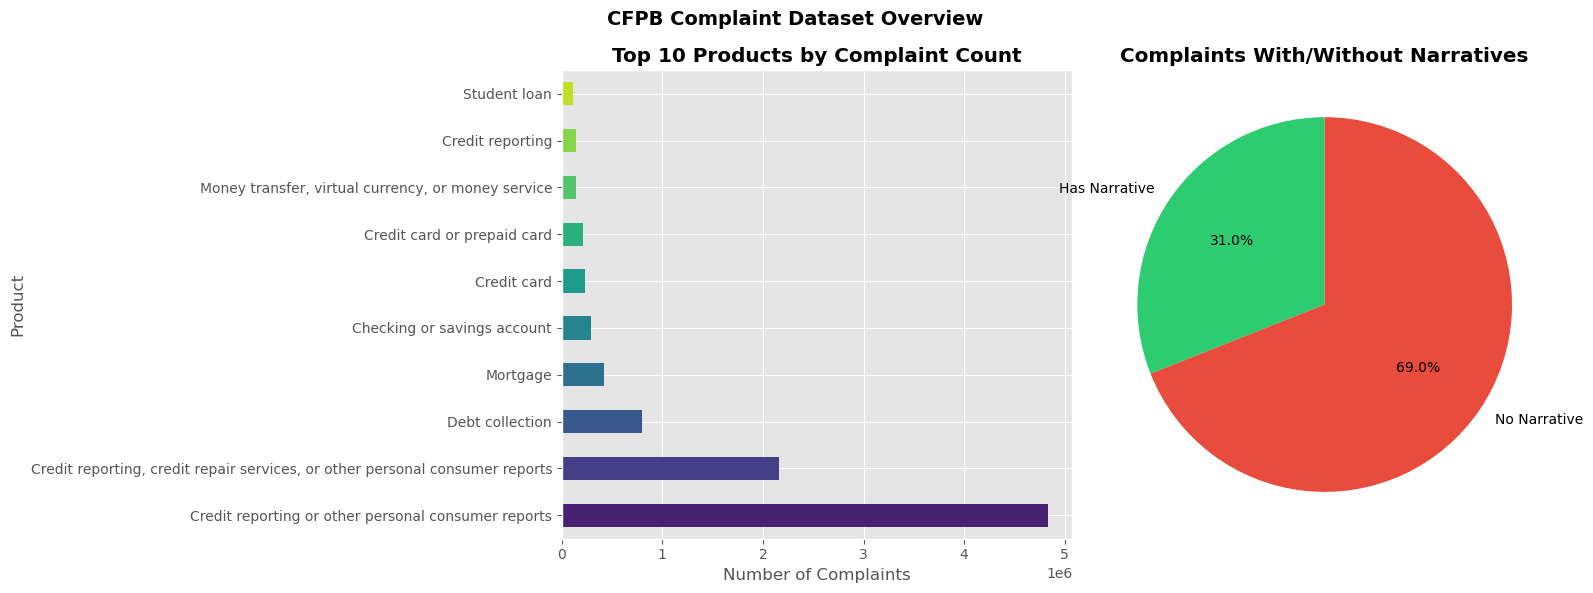

Total complaints: 9,609,797
With narrative: 2,980,756 (31.0%)
Without narrative: 6,629,041


In [5]:
# Distribution of complaints across products
product_col = 'Product' if 'Product' in df.columns else 'product'
product_counts = df[product_col].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

product_counts.head(10).plot(kind='barh', ax=axes[0], color=sns.color_palette('viridis', 10))
axes[0].set_title('Top 10 Products by Complaint Count', fontweight='bold')
axes[0].set_xlabel('Number of Complaints')

# Narrative presence
narrative_col = [c for c in df.columns if 'narrative' in c.lower()][0]
has_narrative = df[narrative_col].notna() & (df[narrative_col].str.strip() != '')
axes[1].pie([has_narrative.sum(), (~has_narrative).sum()],
            labels=['Has Narrative', 'No Narrative'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Complaints With/Without Narratives', fontweight='bold')

plt.suptitle('CFPB Complaint Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total complaints: {len(df):,}')
print(f'With narrative: {has_narrative.sum():,} ({has_narrative.mean()*100:.1f}%)')
print(f'Without narrative: {(~has_narrative).sum():,}')

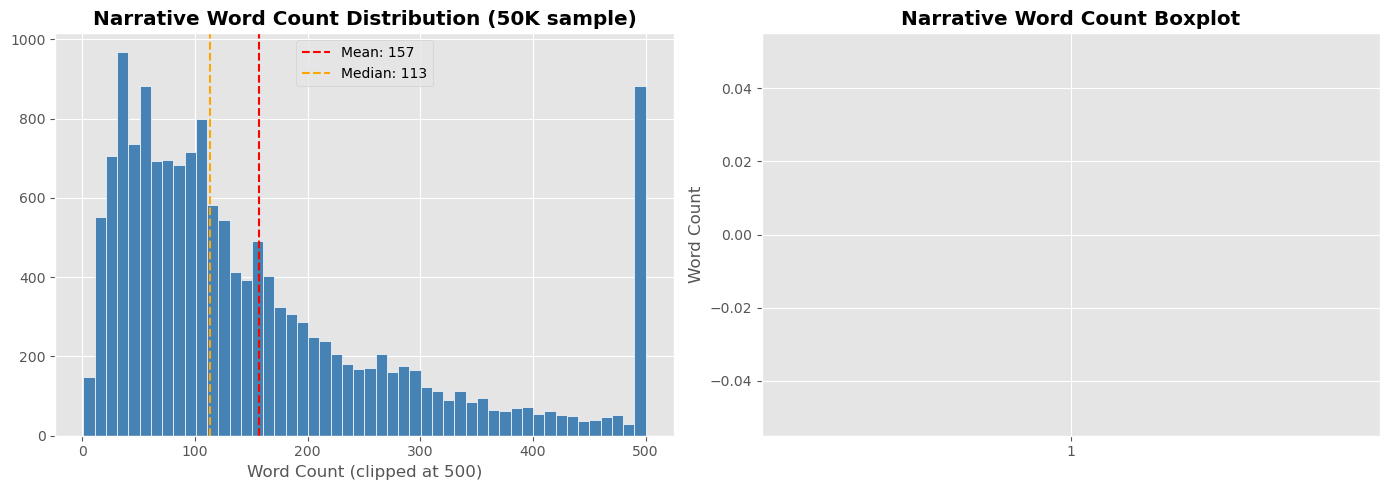

=== Narrative Length Stats (50K sample) ===
count    15448.00
mean       174.94
std        215.86
min          1.00
25%         58.00
50%        113.00
75%        211.00
max       4395.00
Name: word_count, dtype: float64
Very short (<10 words): 117
Very long (>500 words): 844


In [6]:
# Fast narrative length analysis — sample 50K rows
sample = df.sample(min(50000, len(df)), random_state=42)
sample['word_count'] = sample[narrative_col].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

wc = sample['word_count'].clip(0, 500)
axes[0].hist(wc, bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(wc.mean(), color='red', linestyle='--', label=f'Mean: {wc.mean():.0f}')
axes[0].axvline(wc.median(), color='orange', linestyle='--', label=f'Median: {wc.median():.0f}')
axes[0].set_title('Narrative Word Count Distribution (50K sample)', fontweight='bold')
axes[0].set_xlabel('Word Count (clipped at 500)')
axes[0].legend()

axes[1].boxplot(sample['word_count'].clip(0, 1000),
                patch_artist=True, boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Narrative Word Count Boxplot', fontweight='bold')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.savefig('eda_narrative_length.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Narrative Length Stats (50K sample) ===')
print(sample['word_count'].describe().round(2))
print(f'Very short (<10 words): {(sample["word_count"] < 10).sum():,}')
print(f'Very long (>500 words): {(sample["word_count"] > 500).sum():,}')

## 3. Filter to 4 Target Products

In [7]:
# Show all unique products
print('All unique products:')
print(df[product_col].unique())

# Map to 4 categories
product_map = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Consumer Loan': 'Personal Loan',
    'Personal loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan',
    'Bank account or service': 'Savings Account',
    'Checking or savings account': 'Savings Account',
    'Money transfers': 'Money Transfer',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
}

df['product_category'] = df[product_col].map(product_map)
target_products = ['Credit Card', 'Personal Loan', 'Savings Account', 'Money Transfer']
df_filtered = df[df['product_category'].isin(target_products)].copy()
df_filtered = df_filtered[df_filtered[narrative_col].notna()]
df_filtered = df_filtered[df_filtered[narrative_col].str.strip() != '']

print(f'\nFiltered dataset: {df_filtered.shape}')
print(f'\nDistribution by product:')
print(df_filtered['product_category'].value_counts())

All unique products:
['Credit reporting or other personal consumer reports' 'Debt collection'
 'Credit card' 'Checking or savings account'
 'Money transfer, virtual currency, or money service'
 'Vehicle loan or lease' 'Debt or credit management' 'Mortgage'
 'Payday loan, title loan, personal loan, or advance loan' 'Prepaid card'
 'Student loan' 'Credit reporting'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Payday loan, title loan, or personal loan'
 'Bank account or service' 'Money transfers' 'Consumer Loan' 'Payday loan'
 'Other financial service' 'Virtual currency']

Filtered dataset: (478818, 19)

Distribution by product:
product_category
Credit Card        189334
Savings Account    155204
Money Transfer      98685
Personal Loan       35595
Name: count, dtype: int64


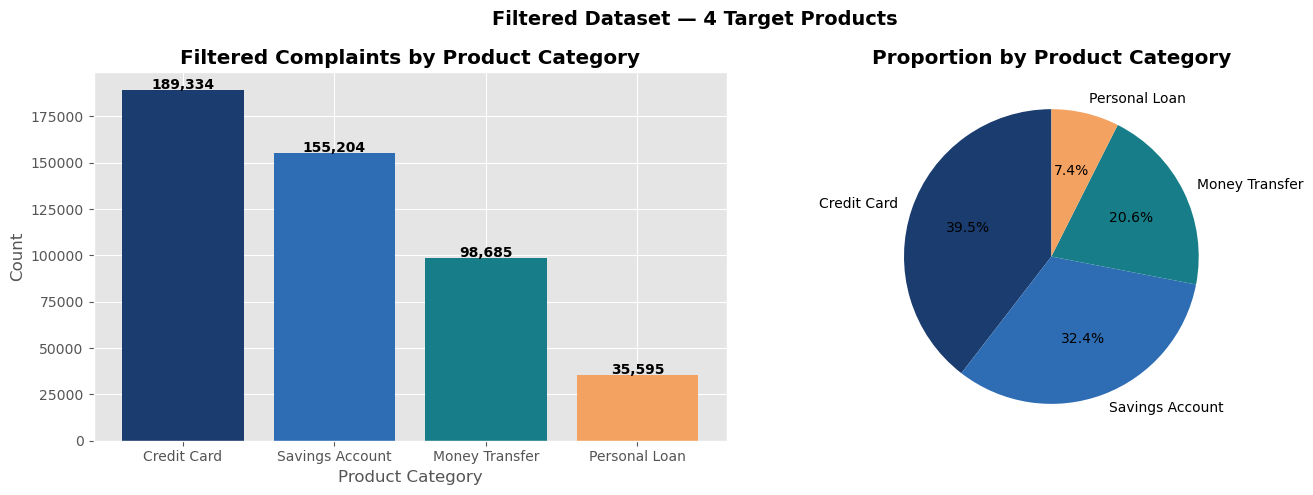

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_filtered['product_category'].value_counts()
colors = ['#1a3c6e','#2e6db4','#177E89','#F4A261']
axes[0].bar(cat_counts.index, cat_counts.values, color=colors)
axes[0].set_title('Filtered Complaints by Product Category', fontweight='bold')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=10)

axes[1].pie(cat_counts.values, labels=cat_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proportion by Product Category', fontweight='bold')

plt.suptitle('Filtered Dataset — 4 Target Products', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_filtered_products.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Text Cleaning

In [9]:
import re

def clean_narrative(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'xxxx|xx/xx/xxxx', '', text)
    text = re.sub(r'[^a-z0-9\s.,!?\'-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Use vectorized pandas instead of apply — much faster
df_filtered['cleaned_narrative'] = (
    df_filtered[narrative_col]
    .str.lower()
    .str.replace(r'xxxx|xx/xx/xxxx', '', regex=True)
    .str.replace(r'[^a-z0-9\s.,!?\'-]', ' ', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
df_filtered['word_count'] = df_filtered['cleaned_narrative'].str.split().str.len()
df_filtered = df_filtered[df_filtered['word_count'] >= 10]

print(f'After cleaning: {df_filtered.shape}')

After cleaning: (476349, 21)


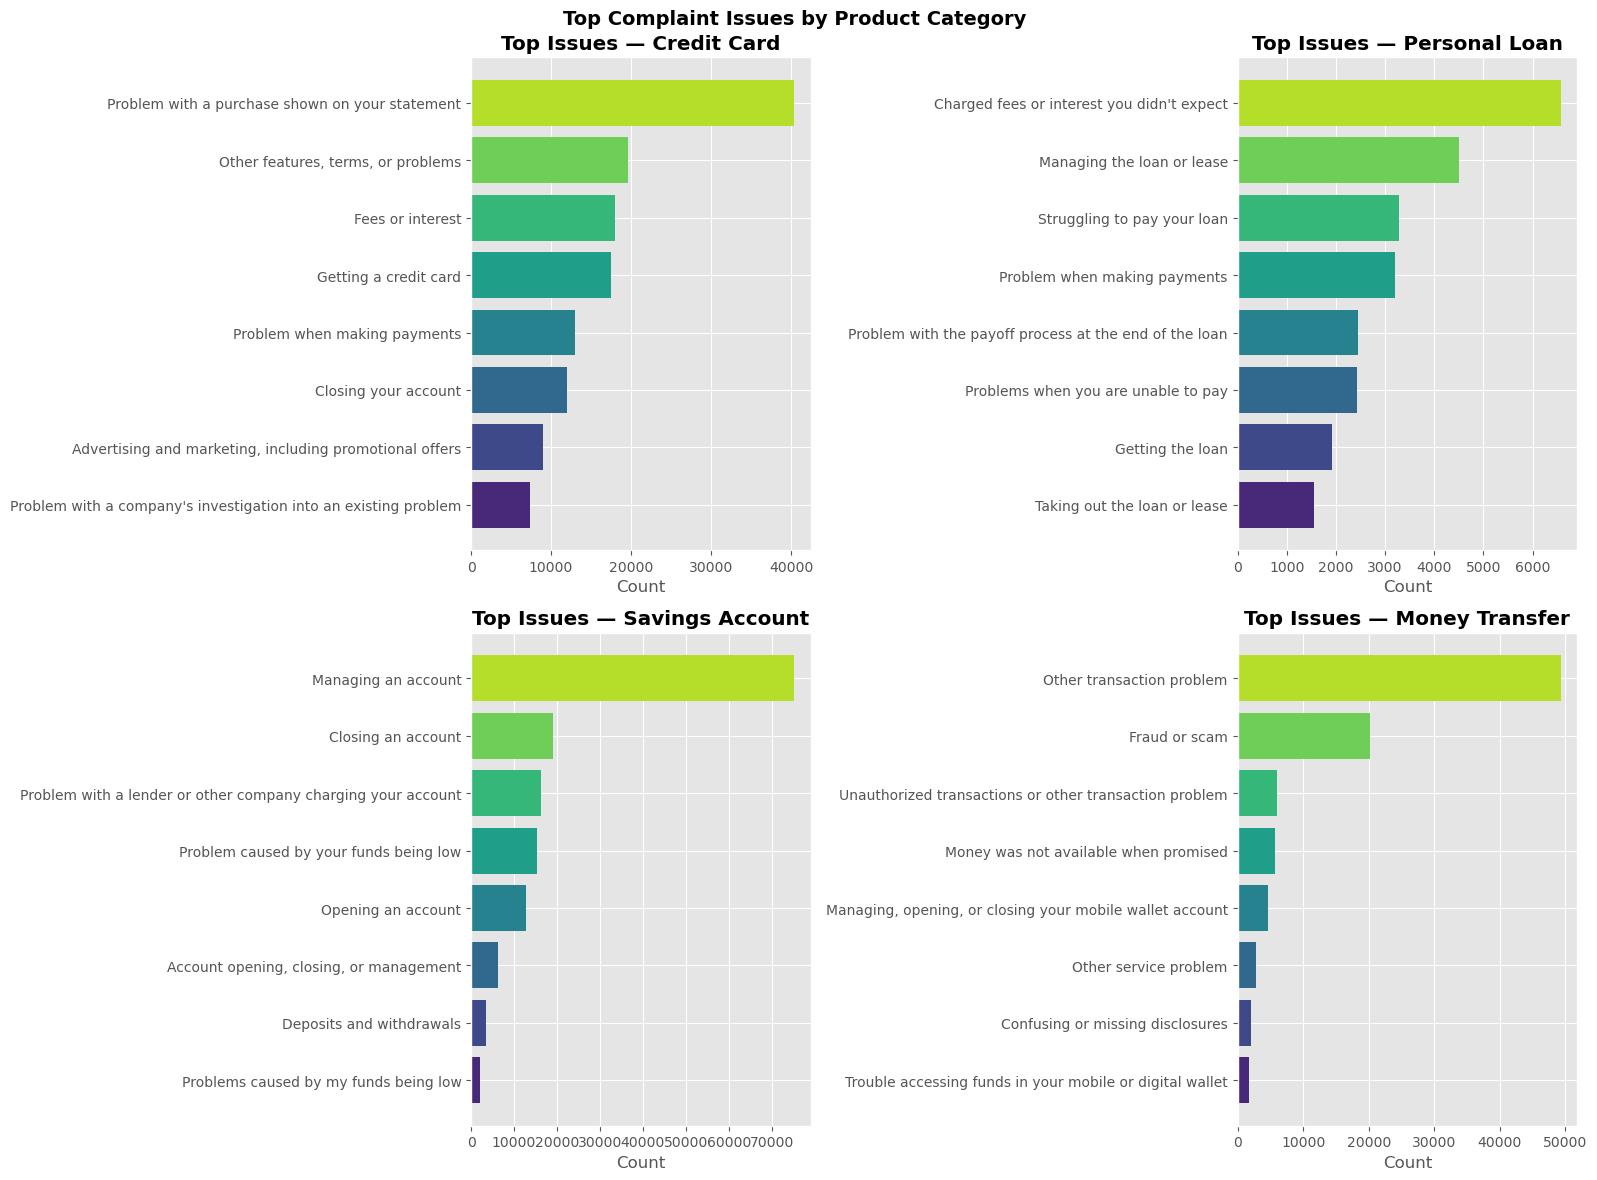

In [10]:
# Issue distribution per product
issue_col = 'Issue' if 'Issue' in df_filtered.columns else 'issue'

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, product in zip(axes.flatten(), target_products):
    subset = df_filtered[df_filtered['product_category'] == product]
    top_issues = subset[issue_col].value_counts().head(8)
    ax.barh(top_issues.index[::-1], top_issues.values[::-1],
            color=sns.color_palette('viridis', len(top_issues)))
    ax.set_title(f'Top Issues — {product}', fontweight='bold')
    ax.set_xlabel('Count')

plt.suptitle('Top Complaint Issues by Product Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_issues_by_product.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Filtered Dataset

In [11]:
# Select relevant columns
cols_to_keep = [
    c for c in [
        'Complaint ID', 'complaint_id', 'Date received',
        product_col, 'product_category', issue_col,
        'Sub-issue', 'Company', 'State',
        narrative_col, 'cleaned_narrative', 'word_count'
    ] if c in df_filtered.columns
]
df_final = df_filtered[cols_to_keep].copy()

os.makedirs('../data/processed', exist_ok=True)
df_final.to_csv('../data/processed/filtered_complaints.csv', index=False)

print(f'Saved filtered_complaints.csv')
print(f'Final shape: {df_final.shape}')
print(f'\nProduct distribution:')
print(df_final['product_category'].value_counts())
print(f'\nKey EDA Findings:')
print(f'- Total complaints after filtering: {len(df_final):,}')
print(f'- Average narrative length: {df_final["word_count"].mean():.0f} words')
print(f'- Credit Card dominates: {(df_final["product_category"]=="Credit Card").mean()*100:.1f}%')

Saved filtered_complaints.csv
Final shape: (476349, 11)

Product distribution:
product_category
Credit Card        188539
Savings Account    154232
Money Transfer      98229
Personal Loan       35349
Name: count, dtype: int64

Key EDA Findings:
- Total complaints after filtering: 476,349
- Average narrative length: 199 words
- Credit Card dominates: 39.6%
